# Customer Churn & Retention Analysis

### Objective
Analyze customer subscription data to understand churn patterns, identify key retention drivers, study customer lifetime trends, and generate actionable business insights to reduce customer loss.

### Tools
- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

### Dataset
Customer Churn & Retention Dataset

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv("customer_churn_retention.csv")

In [4]:
print("Dataset loaded successfully!")
print("Rows and columns:", df.shape)

display(df.head())

Dataset loaded successfully!
Rows and columns: (1000, 12)


,CustomerID,SignupDate,TenureMonths,Plan,Contract,MonthlyCharges,PaymentMethod,InternetService,TechSupport,Churn,ChurnDate,ChurnReason
0,CUST0001,2022-05-11,39,Basic,One year,13.88,Bank transfer,DSL,No,Yes,2025-07-24,Competitor
1,CUST0002,2025-02-04,36,Basic,Month-to-month,23.54,Electronic check,Fiber optic,No,Yes,2028-01-20,Price
2,CUST0003,2024-08-14,27,Basic,Month-to-month,12.99,PayPal,NaN,No,No,NaN,NaN
3,CUST0004,2023-10-04,43,Basic,Month-to-month,17.57,Electronic check,Fiber optic,No,Yes,2027-04-16,Support
4,CUST0005,2023-09-25,7,Pro,Two year,46.07,Bank transfer,Fiber optic,No,Yes,2024-04-22,Price


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   CustomerID       1000 non-null   object 
 1   SignupDate       1000 non-null   object 
 2   TenureMonths     1000 non-null   int64  
 3   Plan             1000 non-null   object 
 4   Contract         1000 non-null   object 
 5   MonthlyCharges   1000 non-null   float64
 6   PaymentMethod    1000 non-null   object 
 7   InternetService  916 non-null    object 
 8   TechSupport      1000 non-null   object 
 9   Churn            1000 non-null   object 
 10  ChurnDate        500 non-null    object 
 11  ChurnReason      500 non-null    object 
dtypes: float64(1), int64(1), object(10)
memory usage: 93.9+ KB


In [6]:
print("\nMissing values:")
display(df.isnull().sum())



Missing values:


CustomerID           0
SignupDate           0
TenureMonths         0
Plan                 0
Contract             0
MonthlyCharges       0
PaymentMethod        0
InternetService     84
TechSupport          0
Churn                0
ChurnDate          500
ChurnReason        500
dtype: int64

In [7]:
print("\nSummary statistics:")
display(df.describe(include="all"))


Summary statistics:


,CustomerID,SignupDate,TenureMonths,Plan,Contract,MonthlyCharges,PaymentMethod,InternetService,TechSupport,Churn,ChurnDate,ChurnReason
count,1000,1000,1000.000000,1000,1000,1000.000000,1000,916,1000,1000,500,500
unique,1000,721,NaN,3,3,NaN,4,2,2,2,437,5
top,CUST0001,2022-07-24,NaN,Basic,Month-to-month,NaN,PayPal,Fiber optic,No,Yes,2025-08-28,Product features
freq,1,6,NaN,505,561,NaN,266,545,503,500,4,104
mean,NaN,NaN,24.351000,NaN,NaN,42.056700,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,14.014071,NaN,NaN,29.080489,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,1.000000,NaN,NaN,5.000000,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,12.000000,NaN,NaN,19.027500,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,24.000000,NaN,NaN,30.265000,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,37.000000,NaN,NaN,51.887500,NaN,NaN,NaN,NaN,NaN,NaN


In [8]:
df = df.drop_duplicates(subset="CustomerID")

In [9]:
df.columns = df.columns.str.strip()

In [10]:
df["SignupDate"] = pd.to_datetime(
    df["SignupDate"], errors="coerce"
)

In [11]:
df["ChurnDate"] = pd.to_datetime(
    df["ChurnDate"], errors="coerce"
)

In [12]:
df["TenureMonths"] = pd.to_numeric(
    df["TenureMonths"], errors="coerce"
)

In [13]:
df["MonthlyCharges"] = pd.to_numeric(
    df["MonthlyCharges"], errors="coerce"
)

In [14]:
df = df.dropna(subset=[
    "CustomerID", "SignupDate",
    "TenureMonths", "Churn"
])

In [15]:
df["Churn"] = df["Churn"].str.strip().str.title()

In [16]:
df["MonthlyCharges"] = df["MonthlyCharges"].fillna(
    df["MonthlyCharges"].median()
)

In [17]:
print("Data cleaning completed!")
print("Final dataset shape:", df.shape)
display(df.head())

Data cleaning completed!
Final dataset shape: (1000, 12)


,CustomerID,SignupDate,TenureMonths,Plan,Contract,MonthlyCharges,PaymentMethod,InternetService,TechSupport,Churn,ChurnDate,ChurnReason
0,CUST0001,2022-05-11,39,Basic,One year,13.88,Bank transfer,DSL,No,Yes,2025-07-24,Competitor
1,CUST0002,2025-02-04,36,Basic,Month-to-month,23.54,Electronic check,Fiber optic,No,Yes,2028-01-20,Price
2,CUST0003,2024-08-14,27,Basic,Month-to-month,12.99,PayPal,NaN,No,No,NaT,NaN
3,CUST0004,2023-10-04,43,Basic,Month-to-month,17.57,Electronic check,Fiber optic,No,Yes,2027-04-16,Support
4,CUST0005,2023-09-25,7,Pro,Two year,46.07,Bank transfer,Fiber optic,No,Yes,2024-04-22,Price


In [18]:
total_customers = len(df)

churned_customers = (df["Churn"] == "Yes").sum()
retained_customers = (df["Churn"] == "No").sum()

churn_rate = churned_customers / total_customers * 100
retention_rate = retained_customers / total_customers * 100


In [19]:
print("Total Customers:", total_customers)
print("Churned Customers:", churned_customers)
print("Retained Customers:", retained_customers)

print(f"Churn Rate: {churn_rate:.2f}%")
print(f"Retention Rate: {retention_rate:.2f}%")

Total Customers: 1000
Churned Customers: 500
Retained Customers: 500
Churn Rate: 50.00%
Retention Rate: 50.00%


In [21]:
plan_churn = df.groupby("Plan").agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

plan_churn["ChurnRate"] = (
    plan_churn["Churned"] /
    plan_churn["Total_Customers"] * 100
)

display(plan_churn)

,Total_Customers,Churned,ChurnRate
Plan,,,
Basic,505,258,51.089109
Enterprise,162,92,56.790123
Pro,333,150,45.045045


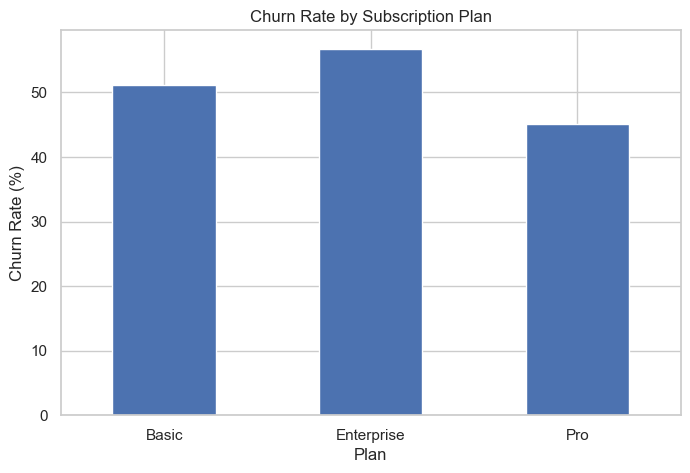

In [25]:
plan_churn["ChurnRate"].plot(
    kind="bar", figsize=(8, 5)
)
plt.title("Churn Rate by Subscription Plan")
plt.xlabel("Plan")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [28]:
contract_churn = df.groupby("Contract").agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

contract_churn["ChurnRate"] = (
    contract_churn["Churned"] /
    contract_churn["Total_Customers"] * 100
)
display(contract_churn)

,Total_Customers,Churned,ChurnRate
Contract,,,
Month-to-month,561,326,58.110517
One year,288,112,38.888889
Two year,151,62,41.059603


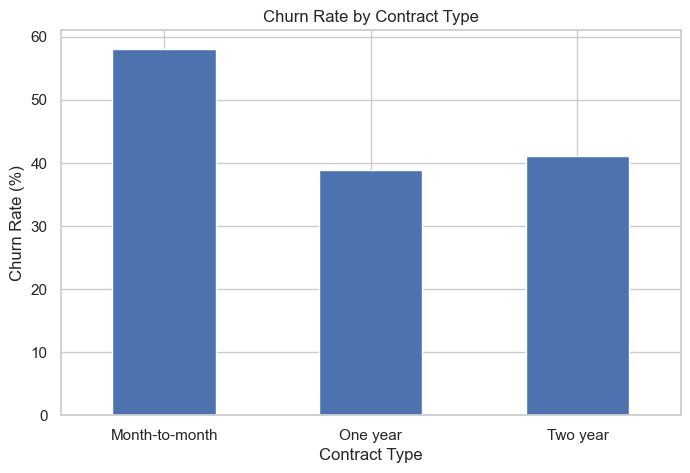

In [29]:
contract_churn["ChurnRate"].plot(
    kind="bar", figsize=(8, 5)
)

plt.title("Churn Rate by Contract Type")
plt.xlabel("Contract Type")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [30]:
df["TenureGroup"] = pd.cut(
    df["TenureMonths"],
    bins=[0, 12, 24, 36, 48],
    labels=[
        "1-12 Months",
        "13-24 Months",
        "25-36 Months",
        "37-48 Months"
    ],
    include_lowest=True
)

tenure_churn = df.groupby(
    "TenureGroup", observed=False
).agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

tenure_churn["ChurnRate"] = (
    tenure_churn["Churned"] /
    tenure_churn["Total_Customers"].replace(0, np.nan) * 100
)

display(tenure_churn)

,Total_Customers,Churned,ChurnRate
TenureGroup,,,
1-12 Months,254,151,59.448819
13-24 Months,253,114,45.059289
25-36 Months,240,111,46.250000
37-48 Months,253,124,49.011858


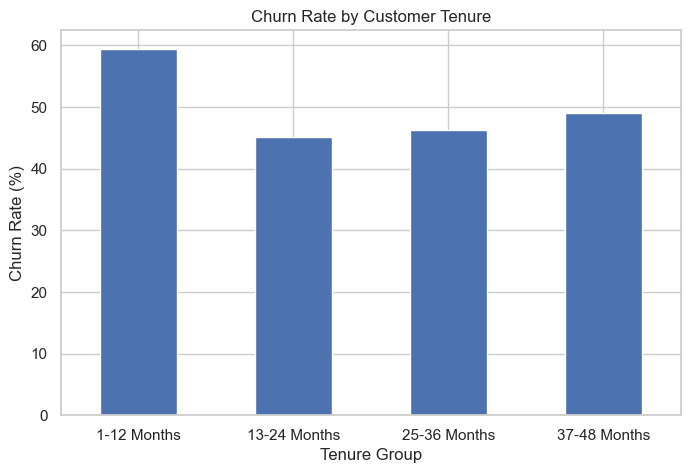

In [31]:
tenure_churn["ChurnRate"].plot(
    kind="bar", figsize=(8, 5)
)

plt.title("Churn Rate by Customer Tenure")
plt.xlabel("Tenure Group")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

In [32]:
churned_df = df[df["Churn"] == "Yes"].copy()

reason_counts = churned_df["ChurnReason"].value_counts()

display(reason_counts)

ChurnReason
Product features    104
Moved/Not needed    104
Support             102
Competitor           96
Price                94
Name: count, dtype: int64

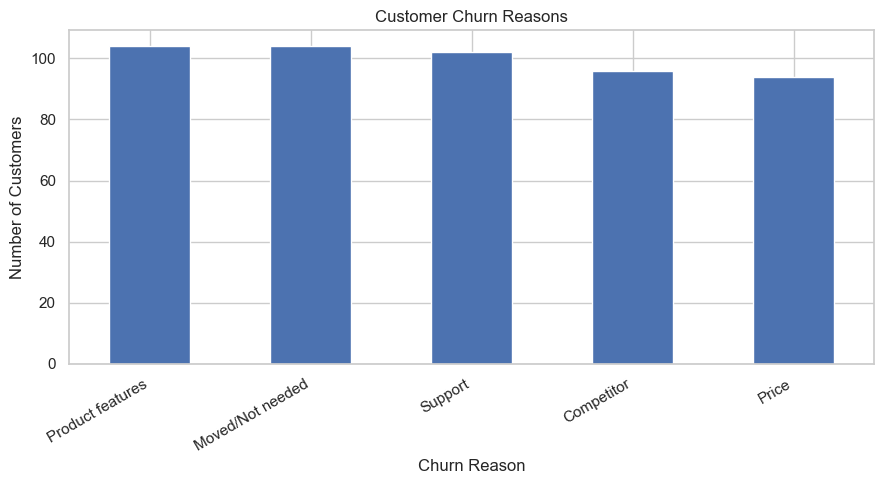

In [33]:
reason_counts.plot(
    kind="bar", figsize=(9, 5)
)

plt.title("Customer Churn Reasons")
plt.xlabel("Churn Reason")
plt.ylabel("Number of Customers")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

In [34]:
payment_churn = df.groupby("PaymentMethod").agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

payment_churn["ChurnRate"] = (
    payment_churn["Churned"] /
    payment_churn["Total_Customers"] * 100
)

display(payment_churn)

,Total_Customers,Churned,ChurnRate
PaymentMethod,,,
Bank transfer,242,119,49.173554
Credit card,241,107,44.398340
Electronic check,251,150,59.760956
PayPal,266,124,46.616541


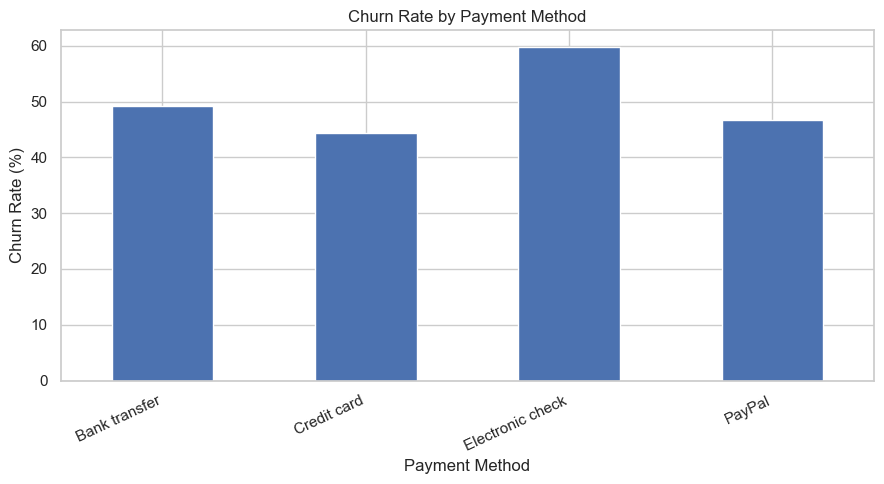

In [35]:
payment_churn["ChurnRate"].plot(
    kind="bar", figsize=(9, 5)
)

plt.title("Churn Rate by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()

In [36]:
support_churn = df.groupby("TechSupport").agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

support_churn["ChurnRate"] = (
    support_churn["Churned"] /
    support_churn["Total_Customers"] * 100
)

display(support_churn)

,Total_Customers,Churned,ChurnRate
TechSupport,,,
No,503,277,55.069583
Yes,497,223,44.869215


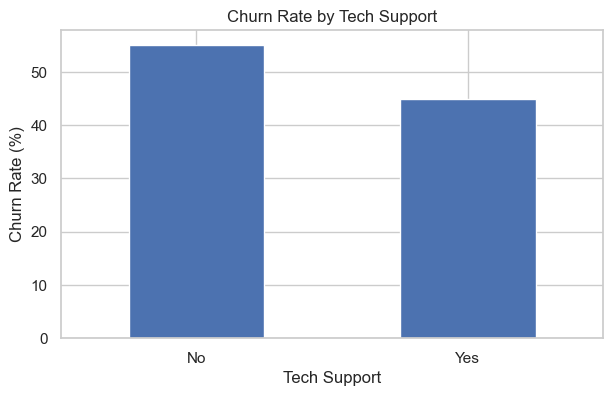

In [37]:
support_churn["ChurnRate"].plot(
    kind="bar", figsize=(7, 4)
)

plt.title("Churn Rate by Tech Support")
plt.xlabel("Tech Support")
plt.ylabel("Churn Rate (%)")
plt.xticks(rotation=0)
plt.show()

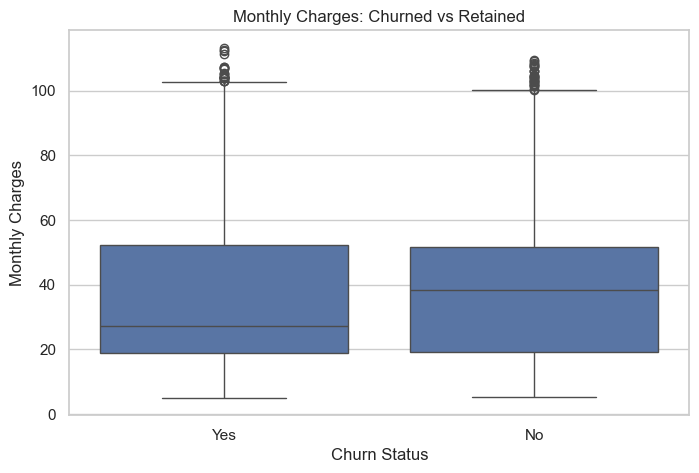

Churn
No     41.4805
Yes    42.6329
Name: MonthlyCharges, dtype: float64

In [39]:
plt.figure(figsize=(8, 5))

sns.boxplot(
    data=df,
    x="Churn",
    y="MonthlyCharges"
)
plt.title("Monthly Charges: Churned vs Retained")
plt.xlabel("Churn Status")
plt.ylabel("Monthly Charges")
plt.show()

display(
    df.groupby("Churn")["MonthlyCharges"].mean()
)

In [41]:
lifetime_analysis = df.groupby("Churn").agg(
    Average_Lifetime=("TenureMonths", "mean"),
    Median_Lifetime=("TenureMonths", "median"),
    Customer_Count=("CustomerID", "count")
)

display(lifetime_analysis)

,Average_Lifetime,Median_Lifetime,Customer_Count
Churn,,,
No,25.352,25.0,500
Yes,23.350,23.0,500


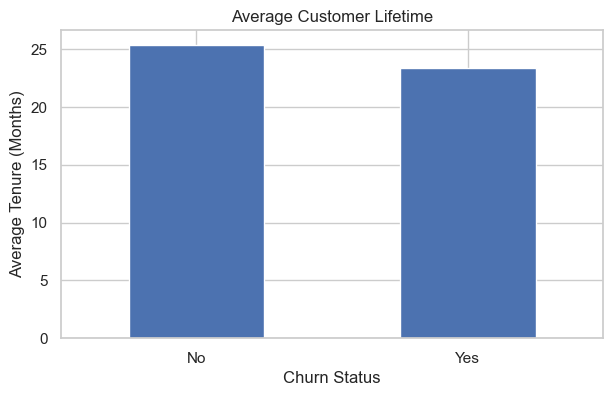

In [42]:
lifetime_analysis["Average_Lifetime"].plot(
    kind="bar", figsize=(7, 4)
)

plt.title("Average Customer Lifetime")
plt.xlabel("Churn Status")
plt.ylabel("Average Tenure (Months)")
plt.xticks(rotation=0)
plt.show()

In [43]:
df["SignupMonth"] = (
    df["SignupDate"].dt.to_period("M").astype(str)
)

cohort_analysis = df.groupby("SignupMonth").agg(
    Total_Customers=("CustomerID", "count"),
    Churned=("Churn", lambda x: (x == "Yes").sum())
)

cohort_analysis["ChurnRate"] = (
    cohort_analysis["Churned"] /
    cohort_analysis["Total_Customers"] * 100
)

cohort_analysis["RetentionRate"] = (
    100 - cohort_analysis["ChurnRate"]
)

display(cohort_analysis)

,Total_Customers,Churned,ChurnRate,RetentionRate
SignupMonth,,,,
2022-01,19,7,36.842105,63.157895
2022-02,18,9,50.000000,50.000000
2022-03,19,7,36.842105,63.157895
2022-04,11,7,63.636364,36.363636
2022-05,31,15,48.387097,51.612903
2022-06,28,14,50.000000,50.000000
2022-07,29,17,58.620690,41.379310
2022-08,27,10,37.037037,62.962963
2022-09,20,10,50.000000,50.000000


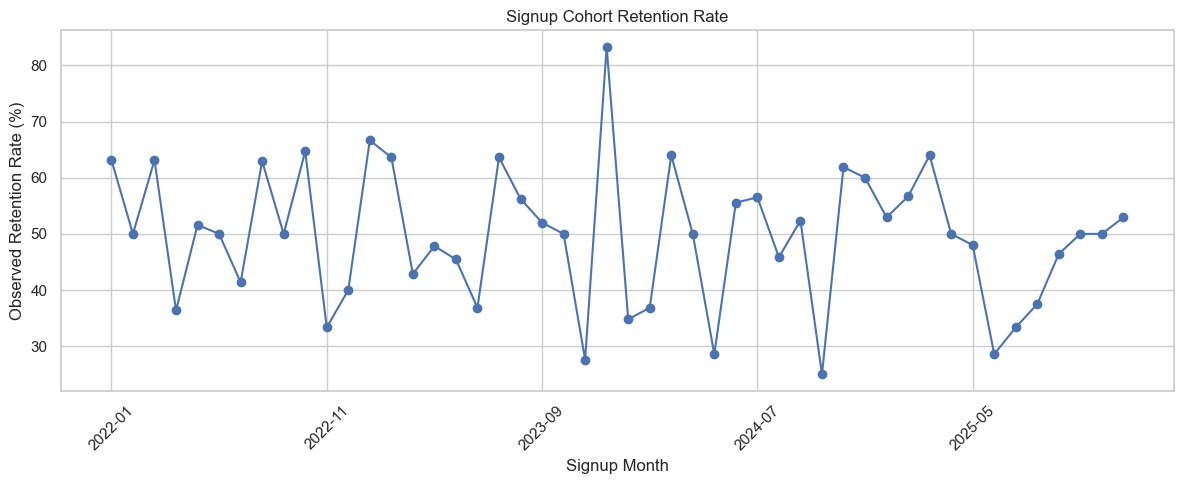

In [44]:
cohort_analysis["RetentionRate"].plot(
    figsize=(12, 5), marker="o"
)

plt.title("Signup Cohort Retention Rate")
plt.xlabel("Signup Month")
plt.ylabel("Observed Retention Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [46]:
summary = pd.DataFrame({
    "Metric": [
        "Total Customers",
        "Churned Customers",
        "Retained Customers",
        "Churn Rate (%)",
        "Retention Rate (%)",
        "Average Tenure (Months)",
        "Average Monthly Charges"
    ],
    "Value": [
        total_customers,
        churned_customers,
        retained_customers,
        round(churn_rate, 2),
        round(retention_rate, 2),
        round(df["TenureMonths"].mean(), 2),
        round(df["MonthlyCharges"].mean(), 2)
    ]
})

display(summary)

,Metric,Value
0,Total Customers,1000.00
1,Churned Customers,500.00
2,Retained Customers,500.00
3,Churn Rate (%),50.00
4,Retention Rate (%),50.00
5,Average Tenure (Months),24.35
6,Average Monthly Charges,42.06


In [47]:
summary.to_csv("churn_summary.csv", index=False)

plan_churn.to_csv("churn_by_plan.csv")
contract_churn.to_csv("churn_by_contract.csv")
tenure_churn.to_csv("churn_by_tenure.csv")
payment_churn.to_csv("churn_by_payment.csv")
support_churn.to_csv("churn_by_support.csv")
cohort_analysis.to_csv("signup_cohort_analysis.csv")

print("All analysis files exported successfully!")

All analysis files exported successfully!


### Key Business Insights

1. The analysis measures the overall customer churn and retention rate to understand the current customer base.

2. Churn varies across different subscription plans, helping identify customer segments with higher observed customer loss.

3. Contract type shows differences in observed churn, with month-to-month customers requiring particular attention.

4. Customer tenure provides insights into customer lifetime and helps identify early and long-term retention patterns.

5. Churn rates vary across different payment methods, indicating areas that may require further investigation.

6. Customers with and without technical support show differences in observed churn rates.

7. The main recorded churn reasons include Price, Support, Product Features, Competitor, and Moved/Not Needed.

8. Signup cohort analysis helps compare observed retention patterns among customers who joined during different periods.

9. Monthly charges can be compared between churned and retained customers to understand differences in customer spending.

10. Customer lifetime analysis provides an overview of the average and median tenure of churned and retained customers.

### Business Recommendations

1. Focus on customers with higher observed churn and develop targeted retention strategies.

2. Improve onboarding and customer engagement, especially for customers during their early subscription period.

3. Monitor month-to-month customers and consider suitable long-term subscription incentives.

4. Improve technical support and proactively address customer service issues.

5. Investigate pricing-related churn and review whether subscription plans provide appropriate value.

6. Analyze product feature feedback to identify improvements that could reduce customer loss.

7. Monitor payment-method-specific churn patterns and investigate potential payment or customer-experience issues.

8. Use customer tenure and cohort information to identify customers who may require additional retention support.

9. Regularly monitor churn reasons and retention metrics to identify changing customer behavior.

10. Validate retention strategies using future customer data and controlled experiments before applying them as fixed business rules.

### Conclusion

This project analyzed customer subscription data to understand customer churn, retention, churn reasons, and customer lifetime trends.

The analysis examined churn across subscription plans, contract types, customer tenure, payment methods, technical support, monthly charges, and signup cohorts.

The results provide a structured understanding of customer behavior and highlight customer segments and factors associated with different observed churn rates.

The findings can support data-driven retention strategies by helping the business improve onboarding, strengthen customer support, investigate pricing and product issues, and monitor high-churn customer segments.

These findings represent relationships observed in the dataset and should be validated with additional business data or controlled experiments before being treated as causal business rules.